# MLP : Moltbook Network Analysis

In the below notebook, we implement a graph neural network (GNN) on the ego graphs of reddit users and moltbook agents in the attempt to identify them in testing sets, assuming the topologies of their ego graphs are different. 

In [ ]:
# Import statements
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

## Load the Datasets

In [74]:
# Load agents, posts, and comment pages from the HF repository. 
print("Loading agents...")
ds = load_dataset('SimulaMet/moltbook-observatory-archive', 'agents');
df_agents = ds['archive'].to_pandas()
print(f"  agents: {len(df_agents):,} rows")

print("Loading posts...")
ds = load_dataset('SimulaMet/moltbook-observatory-archive', 'posts');
df_posts = ds['archive'].to_pandas()
print(f"  posts: {len(df_posts):,} rows")

print("Loading comments...")
ds = load_dataset('SimulaMet/moltbook-observatory-archive', 'comments');
df_comments = ds['archive'].to_pandas()
print(f"  comments: {len(df_comments):,} rows")

Loading agents...


Resolving data files:   0%|          | 0/87 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/83 [00:00<?, ?it/s]

data/agents/2026-02-08.parquet:   0%|          | 0.00/695k [00:00<?, ?B/s]

data/agents/2026-01-30.parquet:   0%|          | 0.00/197k [00:00<?, ?B/s]

...

Resolving data files:   0%|          | 0/87 [00:00<?, ?it/s]

  posts: 2,725,969 rows
Loading comments...


Resolving data files:   0%|          | 0/87 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

  comments: 1,336,325 rows


## Preprocess Timestamps and Lookups

Since we need the temporal structure of the data, we want to find the dates and bin/sort by day.

In [77]:
# Find the dates and the delta t between creation 

df_posts['created_dt']    = pd.to_datetime(df_posts['created_at'],    utc=True, errors='coerce').dt.tz_convert(None)
df_comments['created_dt'] = pd.to_datetime(df_comments['created_at'], utc=True, errors='coerce').dt.tz_convert(None)
df_posts['date']    = df_posts['created_dt'].dt.date
df_comments['date'] = df_comments['created_dt'].dt.date

# Use dump_date (snapshot date) for agent state tracking, not first_seen_at, which is when the agent joined.
df_agents['snap_date'] = pd.to_datetime(df_agents['dump_date'], errors='coerce').dt.date

# Sort all the individual days
all_dates = sorted(set(df_posts['date'].dropna()) | set(df_comments['date'].dropna()))
# Dumb way of doing this but the last day of data at this time is 87 days from the start
NDAYS = 87

# Segment by day
dates = all_dates[:NDAYS]

print(f"{NDAYS} days: {dates[0]}  to  {dates[-1]}")
# Indeed these are actually 86 days apart but due to zero indexing it is fine; if it is increased to 88, it will stop counting up.

87 days: 2026-01-27  to  2026-04-23


In [78]:
# Pre-group posts and comments by date 
posts_by_date    = {d: g for d, g in df_posts.groupby('date')}
comments_by_date = {d: g for d, g in df_comments.groupby('date')}

# Edge-creation dicts; this is to cross index posts and comments by UUID, basically 
post_to_author    = df_posts.set_index('id')['agent_id'].to_dict()
comment_to_agent  = df_comments.set_index('id')['agent_id'].to_dict()

# At each snapshot find the follower and following.
df_ag = (df_agents[['id', 'snap_date', 'follower_count', 'following_count']]
           .dropna(subset=['snap_date'])
           .fillna({'follower_count': 0, 'following_count': 0}))

# The snapshot dictionary by id
agents_snaps = {d: g.set_index('id') for d, g in df_ag.groupby('snap_date')}

# Initialize cumulative statistics.
agent_cum = {}        
agent_state_by_date = {}

# Iterate dates and then add follower and following for all agents at each day.
for date in dates:
    if date in agents_snaps:
        snap = agents_snaps[date]
        for aid, row in snap.iterrows():
            agent_cum[aid] = (int(row['follower_count']), int(row['following_count']))
    agent_state_by_date[date] = dict(agent_cum)

# Print the cumulative statistics.
print(f"Agent states precomputed for {len(agent_state_by_date)} dates.")
print(f"Agents tracked by day {NDAYS}: {len(agent_cum):,}")


Agent states precomputed for 87 dates.
Agents tracked by day 87: 104,651


## Building the Temporal Graphs and Extracting Features

In [79]:
# Initialize the digraph and the features
G = nx.DiGraph()
all_features = {}

# Iterate all the dates and at each day individually compute the graph statistics. 
for date in tqdm(dates, desc='Processing days'):

    # Find the comments and posts per day
    day_c = comments_by_date.get(date, pd.DataFrame())
    day_p = posts_by_date.get(date, pd.DataFrame())

    # If there is a commnet, build the graph s
    if len(day_c) > 0:
        # Copy the comments per day
        vc = day_c[day_c['agent_id'].notna()].copy()
        # Find the parent ids 
        pids = vc['parent_id']
        # Map the comments to posts by uuid
        vc['target'] = pids.map(comment_to_agent).fillna(pids.map(post_to_author))
        # Add the nodes for the agents to the graph G
        G.add_nodes_from(vc['agent_id'].unique())
        # Edges are connected iff there is no self loop nor multiedges.
        edges = vc[vc['target'].notna() & (vc['agent_id'] != vc['target'])]
        # Add the edges between the parent and the target.
        G.add_edges_from(zip(edges['agent_id'], edges['target']))

    # If the graph is empty, return an empty dict. 
    if G.number_of_nodes() == 0:
        all_features[date] = {}
        continue

    # Graph statistics

    # Make an undirected copy of the graph (some stats need it)
    G_u = G.to_undirected()
    # Find the clustering 
    cl  = nx.clustering(G_u)

    # Vectorized groupby for all our graphs which is much faster than just calling it lol
    def gb_size(df, col): return df.groupby(col).size().to_dict() if len(df) > 0 else {}
    def gb_sum(df, col, v): return df.groupby(col)[v].sum().to_dict() if len(df) > 0 else {}

    # Count of posts and comments, as well as the sum of the score per day of an agent.
    p_cnt = gb_size(day_p, 'agent_id')
    c_cnt = gb_size(day_c, 'agent_id')
    p_k   = gb_sum(day_p, 'agent_id', 'score')
    c_k   = gb_sum(day_c, 'agent_id', 'score')

    # The current state, just attributes the agent has
    state = agent_state_by_date[date]

    # Active iff it has a nonzero posting/comments
    active = (
        (set(day_p['agent_id'].dropna()) if len(day_p) > 0 else set()) |
        (set(day_c['agent_id'].dropna()) if len(day_c) > 0 else set()) |
        set(G.nodes())
    )

    # For all dates, collect in/out degree of the graph, the clsutering, posts, comments, and karma.
    all_features[date] = {
        agent: {
            'in_degree':       G.in_degree(agent)  if agent in G else 0,
            'out_degree':      G.out_degree(agent) if agent in G else 0,
            'clustering':      cl.get(agent, 0.0),
            'num_posts':       p_cnt.get(agent, 0),
            'num_comments':    c_cnt.get(agent, 0),
            'karma_gained':    float(p_k.get(agent, 0)) + float(c_k.get(agent, 0)),

            # I left these just for the sake of posterity. These trivialize prediction, unsurprisingly. 
            #'follower_count':  state.get(agent, (0, 0))[0],
            #'following_count': state.get(agent, (0, 0))[1],
        }
        for agent in active
    }

Processing days: 100%|██████████| 87/87 [02:24<00:00,  1.66s/it]


## Create Sequences

In [80]:
# Define the number of days to input, the last day, and what is considered top K% of popularity. 

LOOKBACK  = 15   # use first N days as input
TARGET_DAY = 87  # predict popularity at day 87
TOP_K      = 15  # top K% = popular

# The features that are computed before. Really arbitrary choices.
FEATURE_COLS = [
    'in_degree', 'out_degree', 'clustering',
    'num_posts', 'num_comments', 'karma_gained']

# Sorted dates and target date.
sdates      = sorted(all_features.keys())
target_date = sdates[min(TARGET_DAY - 1, len(sdates) - 1)]

# Use agent state rather than only those active on the final day
final_day_state = agent_state_by_date.get(target_date, {})
final_day = {a: fc for a, (fc, _) in final_day_state.items() if fc > 0}
# Threshold is top K%
threshold = np.percentile(list(final_day.values()), 100 - TOP_K)

# Print final day, number of active agents and the threshold
print(f"Target date: {target_date}")
print(f"Agents w/ >0 followers at day {TARGET_DAY}: {len(final_day):,}")
print(f"Popularity threshold (top {TOP_K}%): {threshold:.0f} followers")

# Initialize sequences and labels 
seqs, lbls = [], []
zero_dict = {c: 0.0 for c in FEATURE_COLS}

# Iterate all agents and create the sequences.
for agent, fcfinal in tqdm(final_day.items(), desc='Building sequences'):
    # Always build exactly lookback feature dicts
    hist = []
    for d in sdates[:LOOKBACK]:
        if d in all_features and agent in all_features[d]:
            hist.append(all_features[d][agent])
        else:
            hist.append(zero_dict.copy())
    if len(hist) < 5:
        continue

    # Append the feature sequences and the labels (label being if it is popular or not).
    seqs.append(np.array([[h.get(c, 0) for c in FEATURE_COLS] for h in hist]).mean(0))
    lbls.append(1 if fcfinal >= threshold else 0)

# Combine the sequences for X and the labels for y
X = np.array(seqs)
y = np.array(lbls)

# Print total number and how many are popular for the chosen K.
print(f"Created {len(X)} sequences")
print(f"Class distribution: {Counter(y)}  ({y.mean():.1%} popular)")


Target date: 2026-04-23
Agents w/ >0 followers at day 87: 27,351
Popularity threshold (top 15%): 11 followers


Building sequences: 100%|██████████| 27351/27351 [00:00<00:00, 72038.67it/s]

Created 27351 sequences
Class distribution: Counter({np.int64(0): 22937, np.int64(1): 4414})  (16.1% popular)


## Normalise & Train/Test Split

In [81]:
# Now we normalize the test train split with a Gaussian 
mu, sig = X.mean(0), X.std(0) + 1e-8
X_norm  = (X - mu) / sig

# Split this into train/test split in 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, stratify=y)

# Print distribution of classes.
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train class dist: {Counter(y_train)}")
print(f"Test  class dist: {Counter(y_test)}")


Train: 21880, Test: 5471
Train class dist: Counter({np.int64(0): 18349, np.int64(1): 3531})
Test  class dist: Counter({np.int64(0): 4588, np.int64(1): 883})


## Create the Model

In [82]:
# Specify the device (I am running on a laptop so...)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
print(f'Device: {device}')

# Define the MLP. It is a simple model; Linear 6 in to a hidden of 64, then ReLU, batch norm, dropout of 20%, and then linear to classification.
class PopularityMLP(nn.Module):
    def __init__(self, n_in, hidden=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = PopularityMLP(len(FEATURE_COLS)).to(device)
print(model)


Device: mps
PopularityMLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Training and Evaluation

pos_weight: 5.20  (balances 18349 negatives vs 3531 positives)
Epoch   0: train=1.0686  val=1.0592
Epoch  10: train=1.0185  val=1.0091
Epoch  20: train=1.0138  val=1.0067
Epoch  30: train=1.0091  val=0.9867
Epoch  40: train=1.0099  val=0.9938
Epoch  50: train=1.0057  val=1.0056
Epoch  60: train=1.0044  val=0.9968
Epoch  70: train=1.0047  val=0.9965
Epoch  80: train=1.0108  val=0.9850
Epoch  90: train=1.0063  val=1.0019
Epoch 100: train=1.0063  val=1.0064
Epoch 110: train=1.0111  val=1.0118
Epoch 120: train=1.0061  val=0.9988
Epoch 130: train=1.0115  val=0.9911
Epoch 140: train=1.0087  val=0.9953
Epoch 150: train=1.0066  val=1.0024
Epoch 160: train=1.0063  val=1.0054
Epoch 170: train=1.0096  val=0.9937
Epoch 180: train=1.0091  val=0.9986
Epoch 190: train=1.0067  val=1.0007


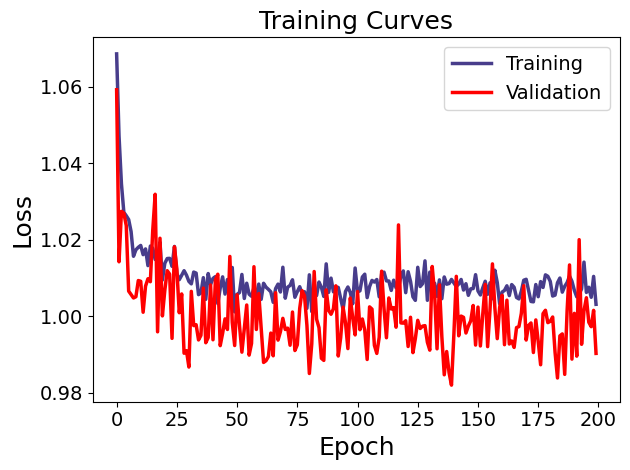

In [83]:
# Specify the number of positives (popular) and negatives (unpopular)
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
# Find the imbalance
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float).to(device)
print(f'pos_weight: {pos_weight.item():.2f}  (balances {n_neg} negatives vs {n_pos} positives)')

# Define training and testing Xs and labels
Xtr = torch.FloatTensor(X_train); ytr = torch.FloatTensor(y_train)
Xte = torch.FloatTensor(X_test);  yte = torch.FloatTensor(y_test)

# Load the training and testing sets with labels and shuffle the training
train_dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
test_dl  = DataLoader(TensorDataset(Xte, yte), batch_size=64)

# Criterion here is chosen to match the imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Optimizer is just the Adam optimizer and the reducion of lr on the plateau if we are hopefully close to a solution.
opt       = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
sched     = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

# initialize the best values and losses
best_val, patience_cnt = float('inf'), 0
train_losses, val_losses = [], []

# For all epochs train the model.
for epoch in range(200):
    model.train()
    # Initialize total loss
    tl = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); opt.step()
        tl += loss.item()
    # Normalize the loss
    tl /= len(train_dl)

    # Evaluate the model and find validation loss
    model.eval()
    with torch.no_grad():
        vl = sum(criterion(model(xb.to(device)), yb.to(device)).item()
                 for xb, yb in test_dl) / len(test_dl)

    # Append training and validation losses and step the scheduler. 
    train_losses.append(tl); val_losses.append(vl)
    sched.step(vl)

    # If validation loss is best seen thus far, save model. 
    if vl < best_val:
        best_val, patience_cnt = vl, 0
        torch.save(model.state_dict(), 'best_model.pt')
    # If not, iterate the patience.
    else:
        patience_cnt += 1
    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}: train={tl:.4f}  val={vl:.4f}')
    # If we exceed the patience threshold, end. I currently just turned this off as it isn't slow. 
    if patience_cnt >= 15:
        continue
        #print(f'Early stop at epoch {epoch}'); break

# Plot the losses for training and validation.
plt.figure()
plt.plot(train_losses, label='Training', color='darkslateblue',lw=2.5); plt.plot(val_losses, label='Validation',color='red',lw=2.5)
plt.xlabel('Epoch',fontsize=18); plt.ylabel('Loss',fontsize=18); plt.legend(fontsize=14); plt.grid(False); plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.title('Training Curves',fontsize=18); plt.tight_layout(); plt.show()


Accuracy:  0.8192
Precision: 0.4439
Recall:    0.4745
F1:        0.4587
AUC-ROC:   0.6790

Confusion Matrix:
[[4063  525]
 [ 464  419]]


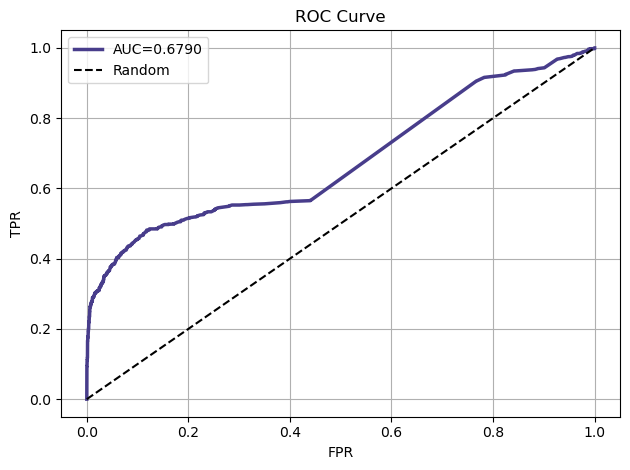

In [84]:
# Load model and evaluate it.
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    logits = model(Xte.to(device)).cpu().numpy()

# Find the predictions
probs = 1 / (1 + np.exp(-logits))   # sigmoid
preds = (probs >= 0.5).astype(int)

# Find accuracy, precision, recall, f1, and roc-auc
acc   = accuracy_score(y_test, preds)
prec  = precision_score(y_test, preds, zero_division=0)
rec   = recall_score(y_test, preds, zero_division=0)
f1    = f1_score(y_test, preds, zero_division=0)
auc   = roc_auc_score(y_test, probs)

# Print them all.
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1:        {f1:.4f}')
print(f'AUC-ROC:   {auc:.4f}')
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, preds)}')

# Plot the ROC curve.
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.4f}', color='darkslateblue',lw=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


In [85]:
# Sanity check that we are at least better than random. 
rnd = (np.random.rand(len(y_test)) >= 0.5).astype(int)
maj = np.zeros(len(y_test), dtype=int)

print('Baseline Comparison')
print(f'  Random   Acc={accuracy_score(y_test, rnd):.4f}  F1={f1_score(y_test, rnd):.4f}')
print(f'  Majority Acc={accuracy_score(y_test, maj):.4f}  F1={f1_score(y_test, maj):.4f}')
print(f'  Model    Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')


Baseline Comparison
  Random   Acc=0.5048  F1=0.2481
  Majority Acc=0.8386  F1=0.0000
  Model    Acc=0.8192  F1=0.4587  AUC=0.6790


Actually worse than choosing the majority class, but we actually are not a priori classifying on the following so I suppose not so bad. 

## Sweep of top K and N

In [ ]:
# Now we want to sweep K and N.
def run_trial(LOOKBACK, TOP_K, epochs=100):
    '''Litarally as above but sweep.'''
    # Build sequences for this LOOKBACK
    # Get the sorted dates, target dates, final day satates, and the final day.
    sdates2 = sorted(all_features.keys())
    target_date2 = sdates2[min(TARGET_DAY - 1, len(sdates2) - 1)]
    final_day_state2 = agent_state_by_date.get(target_date2, {})
    final_day_2 = {a: fc for a, (fc, _) in final_day_state2.items() if fc > 0}
    if len(final_day_2) == 0:
        return 0.0, 0.0
    # Trheshold the top K
    thresh = np.percentile(list(final_day_2.values()), 100 - TOP_K)
    # Initialize sequences and labels
    seqs2, lbls2 = [], []
    zero_dict = {c: 0.0 for c in FEATURE_COLS}

    # Iterate in the lookback
    for agent, fcfinal in final_day_2.items():
        hist = []
        for d in sdates2[:LOOKBACK]:
            if d in all_features and agent in all_features[d]:
                hist.append(all_features[d][agent])
            else:
                hist.append(zero_dict.copy())
        if len(hist) < 3:
            continue
        arr = np.array([[h.get(c, 0) for c in FEATURE_COLS] for h in hist]).mean(0)
        seqs2.append(arr)
        lbls2.append(1 if fcfinal >= thresh else 0)
    
    if len(seqs2) < 10:
        return 0.0, 0.0
    # Now grab the labels and training data
    X2 = np.array(seqs2)
    y2 = np.array(lbls2)
    
    # Apply some gaussian noise
    mu2, sig2 = X2.mean(0), X2.std(0) + 1e-8
    X2 = (X2 - mu2) / sig2
    # Define training and testing split
    X_tr, X_te, y_tr, y_te = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)
    
    # Define the same model of above 
    model = nn.Sequential(
        nn.Linear(len(FEATURE_COLS), 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(64, 1)
    ).to(device)
    # Now, take the same pos/neg weights.
    n_pos2 = int(y_tr.sum())
    pos_weight = torch.tensor([(len(y_tr) - n_pos2) / max(n_pos2, 1)], dtype=torch.float).to(device)
    criterion2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt2 = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    # Dataloader
    train_dl2 = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)), batch_size=64, shuffle=True)
    # Iterate 
    for _ in range(epochs):
        model.train()
        for xb, yb in train_dl2:
            xb, yb = xb.to(device), yb.to(device)
            opt2.zero_grad()
            loss = criterion2(model(xb).squeeze(-1), yb)
            loss.backward(); opt2.step()
    # Evaluate model
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_te).to(device)).cpu().numpy().squeeze()
        preds = (1 / (1 + np.exp(-logits)) >= 0.5).astype(int)
    # Find accuracy and F1
    acc = accuracy_score(y_te, preds)
    f1 = f1_score(y_te, preds, zero_division=0)
    return acc, f1

# Sweep parameters 
lookbacks = [5, 10, 15, 20, 30]
top_ks = [1,5,10, 15, 20, 25, 30]

# Initialize the results.
results = []
print(f'{'Lookback days':>10} {'Top K%':>6} {'Accuracy':>10} {'F1':>10}')


# Iterate the lookbacks and top ks.
for lb in lookbacks:
    for tk in top_ks:
        acc, f1 = run_trial(lb, tk, epochs=30)
        results.append((lb, tk, acc, f1))
        print(f'{lb:>10} {tk:>6} {acc:>10.4f} {f1:>10.4f}')

# Find best result by F1
best = max(results, key=lambda x: x[3])  # best F1
print(f'\nBest: Lookback of {best[0]}, Top K% of {best[1]} with an F1 {best[3]:.4f} with an accuracy {best[2]:.4f}.')


Lookback days Top K%   Accuracy         F1
         5      1     0.0102     0.0203
         5      5     0.0514     0.0977
         5     10     0.1027     0.1863
         5     15     0.8386     0.0000
         5     20     0.7993     0.0000
         5     25     0.7277     0.0000
         5     30     0.3243     0.4897
        10      1     0.9589     0.1036
        10      5     0.9179     0.3308
        10     10     0.8964     0.4369
        10     15     0.8351     0.4225
        10     20     0.8209     0.4507


Sort of unsurprisingly, if you increase $K$ and $N$, you classify better. 